In [2]:
import numpy as np
import scipy as scipy
import scipy.special
import matplotlib.pyplot as plt
import time
import uncertainties as error

***Problem 1***

Part a.)
Show $\langle m \rangle $ for the Poission distribution $p(m|\lambda)=\frac{\lambda^m}{m!}e^{-\lambda} $is $ \langle \lambda \rangle$

\begin{aligned}
\text{Use the expectation value formula } \langle m \rangle  &= \sum m\frac{\lambda^m}{m!}e^{-\lambda}\\ 
\text{Pull out constants } &= e^{-\lambda}\sum m\frac{\lambda^m}{m!} \\
\text{Use m!=m*(m-1)! } &= e^{-\lambda}\sum \frac{\lambda^m}{(m-1)!} \\
\text{Pull out a factor of lambda so exponents match } &= \lambda e^{-\lambda}\sum \frac{\lambda^{m-1}}{(m-1)!} \\
\text{Recognize sum for $e^x$ } &= \lambda e^{-\lambda}e^{\lambda} \\
\text{Cancel out $e^{\lambda} e^{-\lambda}$ } &= \lambda \\
\langle m \rangle &= \lambda
\end{aligned}

Part b.)
Show Var(m) for the Poission distribution $p(m|\lambda)=\frac{\lambda^m}{m!}e^{-\lambda} $is $ \langle \lambda \rangle$

\begin{aligned}
\text{Use the variance formula } Var(m)  &= \langle m^2 \rangle - \langle m \rangle ^2 \\ 
\text{Reformat } \langle m^2 \rangle &= \langle m(m-1) + m \rangle \\
&= \langle m(m-1) \rangle + \langle m \rangle \\
\text{Solve for } \langle m(m-1) \rangle &= \sum m(m-1) \frac{\lambda^m}{m!}e^{-\lambda} \\
\text{We do the trick with factorials again } &= e^{-\lambda}\sum \frac{\lambda^m}{(m-2)!} \\
&= e^{-\lambda}\lambda^2 \sum \frac{\lambda^{m-2}}{(m-2)!} \\
&= e^{-\lambda}\lambda^2 e^{\lambda} \\
\langle m(m-1) \rangle &= \lambda^2 \\
\text{Plus this into the $\langle m^2 \rangle$ formula } \langle m^2 \rangle &= \langle m(m-1) \rangle + \langle m \rangle \\
&= \lambda^2 + \lambda \\
\text{And back to } Var(m) &= \langle m^2 \rangle - \langle m \rangle ^2 \\
&= \lambda^2+\lambda-\lambda^2 \\
&= \lambda \\
\end{aligned}

Part c.) Prove the sum of 2 independent Poisson distributions is also a Poisson distribution

\begin{aligned}
P(z)  &= P(x, y) \\ 
\text{Reverse marginilization }P(z=k)  &= \sum_{m=0}^{k} P(x=k, y=k-m) \\ 
\text{Use the fact x and y are independent }P(z=k)  &= \sum_{m=0}^{k} P(x=k)P(y=k-m) \\
\text{Sub in Poisson distribution formulas }P(z=k)  &= \sum_{m=0}^{k} \frac{\lambda_x^k}{k!}e^{-\lambda_x} \frac{\lambda_y^{k-m}}{(k-m)!}e^{-\lambda_y} \\
\text{Move out constants } &= e^{-\lambda_x}e^{-\lambda_y} \sum_{m=0}^{k} \frac{\lambda_x^k\lambda_y^{k-m}}{k!(k-m)!} \\
\text{Denominator is almost n choose k. Multiply by $\frac{k!}{k!}$ } &= \frac{e^{-(\lambda_x+\lambda_y)}}{k!} \sum_{m=0}^{k} \frac{k!\lambda_x^k\lambda_y^{k-m}}{k!(k-m)!} \\
\text{Use n choose k } &= \frac{e^{-(\lambda_x+\lambda_y)}}{k!} \sum_{m=0}^{k}(\lambda_x^k\lambda_y^{k-m}{k\choose m}) \\
\text{Use Binomial } &= \frac{e^{-(\lambda_x+\lambda_y)}}{k!} (\lambda_x+\lambda_y)^k \\
\text{Let $\lambda_z = \lambda_x+\lambda_y$ } P(z=k) &= \frac{e^{-\lambda_z}}{k!} \lambda_z^k \\
\text{This is Poisson } P(z=k) &= \frac{\lambda_z^k}{k!}e^{-\lambda_z}  \\
\end{aligned}

***Problem 2***

In [27]:
loopLimit = [10, 100, 1000, 5000, 10000, 20000, 100000]
#this way I can make new runtime analysis easy

C:\Users\andre\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


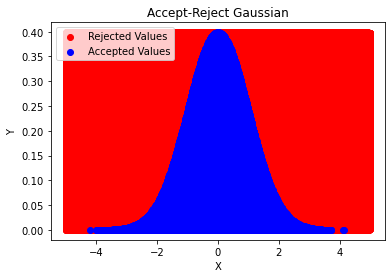

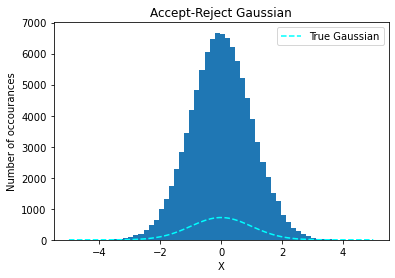

In [28]:
#Accept-Reject Method
#For this method we generate a random number and compare it to the Gaussian to see if it is within or outside
#Let's just do a Uniform envelope function
#Last pages of Lecture 6 notes

#Let's define a Gaussian function
def Gaussian(x, mean, sigma):
    return(1/(sigma * np.sqrt(2*np.pi))*np.exp(-1/2 * ((x-mean)/(sigma))**2))


mean=0
sigma=1

runtimesAcceptReject=[]
for i in range(len(loopLimit)):
    AcceptedValues=[]
    RejectedValues=[]

    timeStart=time.perf_counter()

    while(len(AcceptedValues) < loopLimit[i]):

        inputs = np.random.random() * 10 - 5 #Just going to move this from [0, 1) to [-5, 5)
        GaussianValues = Gaussian(inputs, mean, sigma)
        comparisonValues=np.random.random() / (sigma*np.sqrt(2*np.pi)) #making this go from 0 to max(Gaussian)

        if(comparisonValues > GaussianValues):
            RejectedValues.append([inputs, comparisonValues])
        elif(comparisonValues <= GaussianValues):
            AcceptedValues.append([inputs, comparisonValues])
        else:
            print('This should never print')
            
    timeStop=time.perf_counter()
    runtime = timeStop - timeStart
    runtimesAcceptReject.append(runtime)

tempx=[]
tempy=[]
for i in range(len(RejectedValues)):
    tempx.append(RejectedValues[i][0])
    tempy.append(RejectedValues[i][1])
plt.scatter(tempx, tempy, color='red', label='Rejected Values')
tempx=[] #man I hate this, lemme itterate on this and see if there is a better way
tempy=[]
for i in range(len(AcceptedValues)):
    tempx.append(AcceptedValues[i][0])
    tempy.append(AcceptedValues[i][1])


plt.scatter(tempx, tempy, color='blue', label='Accepted Values')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Accept-Reject Gaussian')
plt.legend()
plt.show()

plt.hist(tempx, bins=50)
plt.plot(np.linspace(-5, 5, 100), 1800*Gaussian(np.linspace(-5, 5, 100), 0, 1), linestyle='--', color='cyan', label = 'True Gaussian')
plt.title('Accept-Reject Gaussian')
plt.xlabel('X')
plt.ylabel('Number of occourances')
plt.legend()
plt.show()

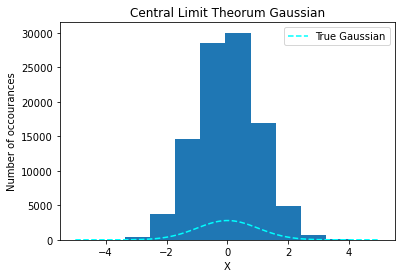

In [29]:
#Central Limit Theorum
#The uniform distribution has average 1/2, variance 1/12
#making N uniform numbers, that collection has average N/2, variance N/12
#we want N to be 12, so variance will now be 1. Then we nudge it by N/2 to set the mean to 0
runtimesCentralLimit=[]

for i in range(len(loopLimit)):
    gaussianValues=[]
    timeStart=time.perf_counter()
    for i in range(loopLimit[i]):
        N=12
        values = np.random.random(N)
        gaussianValues.append(np.sum(values) - N/2)

    timeStop=time.perf_counter()
    runtime = timeStop - timeStart
    runtimesCentralLimit.append(runtime)

plt.hist(gaussianValues)
plt.plot(np.linspace(-5, 5, 100), 7000*Gaussian(np.linspace(-5, 5, 100), 0, 1), linestyle='--', color='cyan', label = 'True Gaussian')
plt.title('Central Limit Theorum Gaussian')
plt.xlabel('X')
plt.ylabel('Number of occourances')
plt.legend()
plt.show()

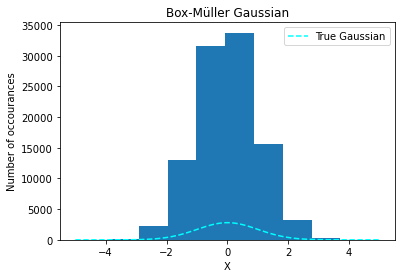

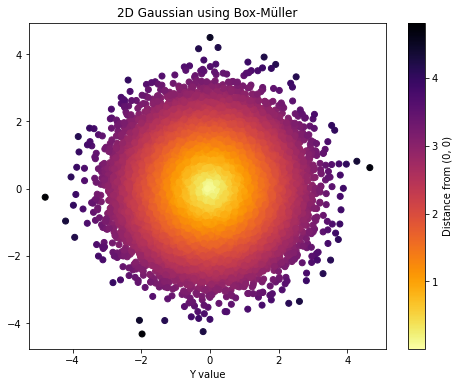

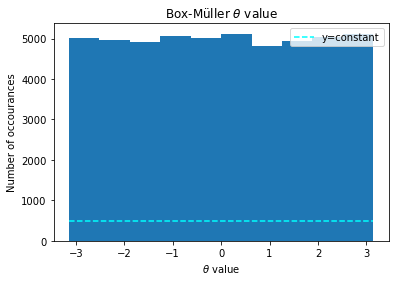

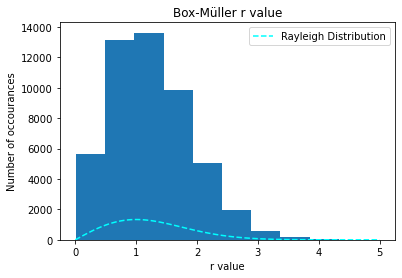

In [30]:
#Box-Mueller
runtimesBoxMuller=[]
for i in range(len(loopLimit)):
    gaussianValues=[]
    xvalues=[]
    yvalues=[]
    timeStart=time.perf_counter()

    while len(gaussianValues) < loopLimit[i]:
        u=np.random.random()
        v=np.random.random()
        x=np.sqrt(-2*np.log(u))*np.cos(2*np.pi*v)
        y=np.sqrt(-2*np.log(u))*np.sin(2*np.pi*v)
        xvalues.append(x)
        yvalues.append(y)
        gaussianValues.append(x)
        gaussianValues.append(y)

    timeStop=time.perf_counter()
    runtime = timeStop - timeStart
    runtimesBoxMuller.append(runtime)

plt.hist(gaussianValues)
plt.plot(np.linspace(-5, 5, 100), 7000*Gaussian(np.linspace(-5, 5, 100), 0, 1), linestyle='--', color='cyan', label = 'True Gaussian')
plt.title('Box-Müller Gaussian')
plt.xlabel('X')
plt.ylabel('Number of occourances')
plt.legend()
plt.show()

plt.figure(figsize=(8, 6)) #maybe I should compute the actual covariance for x and y
plt.scatter(xvalues, yvalues, c=np.sqrt(np.array(xvalues)**2+np.array(yvalues)**2), cmap='inferno_r')
plt.title('2D Gaussian using Box-Müller')
plt.xlabel('X value')
plt.xlabel('Y value')
plt.colorbar(label='Distance from (0, 0)')
plt.show()

#Now let's show what r and theta look like. We have the x and y values so we can just do the things
rvalues=np.sqrt(np.array(xvalues)**2+np.array(yvalues)**2)
thetavalues=np.arctan2(np.array(xvalues), np.array(yvalues))
plt.hist(thetavalues)
plt.plot([-np.pi, np.pi], [500, 500], label='y=constant', linestyle='--', color='cyan')
plt.title(r'Box-Müller $\theta$ value')
plt.xlabel(r'$\theta$ value')
plt.ylabel('Number of occourances')
plt.legend()
plt.show()

def Rayleigh(x, sigma):
    return(x/(sigma**2)*np.exp(-x**2/(2*sigma**2)))

plt.hist(rvalues)
plt.plot(np.linspace(0, 5, 100), 2200*Rayleigh(np.linspace(0, 5, 100), 1), label='Rayleigh Distribution', linestyle='--', color='cyan')
plt.title('Box-Müller r value')
plt.xlabel('r value')
plt.ylabel('Number of occourances')
plt.legend()
plt.show()

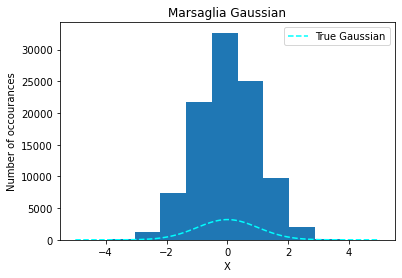

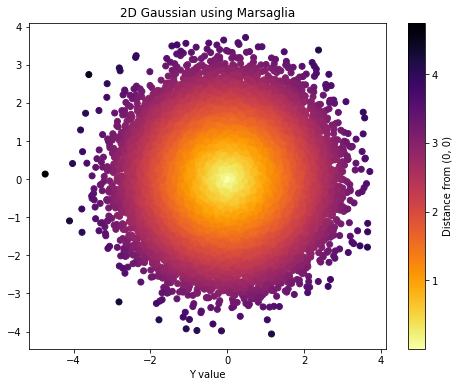

In [31]:
#Marsaglia Method
runtimesMarsaglia=[]

for i in range(len(loopLimit)):
    timeStart=time.perf_counter()
    gaussianValues=[]
    xvalues=[]
    yvalues=[]

    while len(gaussianValues) < loopLimit[i]:
        u=np.random.random()
        v=np.random.random()
        x=2*u - 1
        y=2*v - 1
        s=x**2+y**2
        if(s>1):
            pass
        else:
            x=np.sqrt(-2 * np.log(s)) * x/np.sqrt(s)
            y=np.sqrt(-2 * np.log(s)) * y/np.sqrt(s)
            xvalues.append(x)
            yvalues.append(y)
            gaussianValues.append(x)
            gaussianValues.append(y)

    timeStop=time.perf_counter()
    runtime = timeStop - timeStart
    runtimesMarsaglia.append(runtime)

plt.hist(gaussianValues)
plt.plot(np.linspace(-5, 5, 100), 8000*Gaussian(np.linspace(-5, 5, 100), 0, 1), linestyle='--', color='cyan', label = 'True Gaussian')
plt.title('Marsaglia Gaussian')
plt.xlabel('X')
plt.ylabel('Number of occourances')
plt.legend()
plt.show()

plt.figure(figsize=(8, 6)) #maybe I should compute the actual covariance for x and y
plt.scatter(xvalues, yvalues, c=np.sqrt(np.array(xvalues)**2+np.array(yvalues)**2), cmap='inferno_r')
plt.title('2D Gaussian using Marsaglia')
plt.xlabel('X value')
plt.xlabel('Y value')
plt.colorbar(label='Distance from (0, 0)')
plt.show()

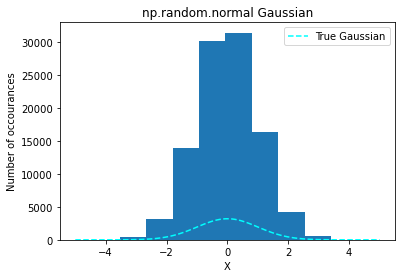

In [32]:
#Lastly we do for just np.random.normal
runtimesnumpy=[]

for i in range(len(loopLimit)):
    timeStart=time.perf_counter()

    gaussianValues = np.random.normal(0, 1, loopLimit[i])

    timeStop=time.perf_counter()
    runtime = timeStop - timeStart
    runtimesnumpy.append(runtime)

plt.hist(gaussianValues)
plt.plot(np.linspace(-5, 5, 100), 8000*Gaussian(np.linspace(-5, 5, 100), 0, 1), linestyle='--', color='cyan', label = 'True Gaussian')
plt.title('np.random.normal Gaussian')
plt.xlabel('X')
plt.ylabel('Number of occourances')
plt.legend()
plt.show()

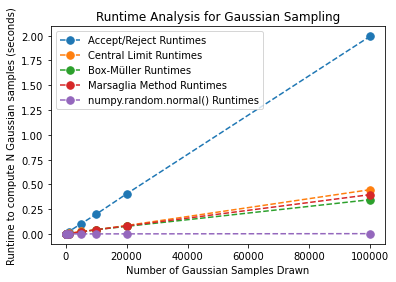

In [47]:
#I'll collect the times I get. This may change depending on hardware but these are my values
#for 10000 gaussian random numbers

#Accept Reject: Runtime: 0.3804010000000062 seconds
#Central Limit: Runtime: 0.07054260000040813 seconds
#Box-Muller: Runtime: 0.04970250000042142 seconds
#Marsaglia: Runtime: 0.05181570000058855 seconds
#numpy: Runtime: 0.000404200007324107 seconds

#so numpy is way more optimized lol. Might also be doing stuff in parallel
#A better way to quantify this would be to do time tests of various sizes, and find the Big O notation value for these
#O(function)=some function of N. Better implementations have a function of N that grows slower
#O(accept/reject) is probably limited by the reject samples. It's probably O(n)=n (doubling the samples doubles the time)
#well actually these all are probably O(n)=n thinking about it. Besides numpy which I can't find anyhthing on
#at least O(n)=n dropping constants and higher-order terms. For n=10000 these might matter a lot more though

plt.plot(loopLimit, runtimesAcceptReject, label = 'Accept/Reject Runtimes', linestyle='--', marker='.', ms=15)
plt.plot(loopLimit, runtimesCentralLimit, label = 'Central Limit Runtimes', linestyle='--', marker='.', ms=15)
plt.plot(loopLimit, runtimesBoxMuller, label = 'Box-Müller Runtimes', linestyle='--', marker='.', ms=15)
plt.plot(loopLimit, runtimesMarsaglia, label = 'Marsaglia Method Runtimes', linestyle='--', marker='.', ms=15)
plt.plot(loopLimit, runtimesnumpy, label = 'numpy.random.normal() Runtimes', linestyle='--', marker='.', ms=15)
plt.xlabel('Number of Gaussian Samples Drawn')
plt.ylabel('Runtime to compute N Gaussian samples (seconds)')
plt.title('Runtime Analysis for Gaussian Sampling')
plt.legend()
plt.show()

***Problem 3***

In [3]:
#Monte Carlo Integration
#let's make the functions
def GaussianSet(x, mean=0, sigma=1): #just an example function before I swap to doing Gamma function
    return(1/(sigma * np.sqrt(2*np.pi))*np.exp(-1/2 * ((x-mean)/(sigma))**2)) #make sure I integrate right

def Expectation(Function, N, startpoint, endpoint): 
    temp=[]
    for i in range(N): #i may be dumb but I needed a way to do this and a loop seemed the easiest
        tester=np.random.rand()
        tester=tester*(endpoint-startpoint) + startpoint
        temp.append(Function(tester))
    return (1/N)*np.sum(temp)

def MCIntegral(Function, N, startpoint, endpoint): #this one is pretty much just a drop in
    return((endpoint-startpoint)*Expectation(Function, N, startpoint, endpoint)) 

def MCIntegralUncertainty(Function, N, startpoint, endpoint): #this one is a little funnier
    f_mean = Expectation(Function, N, startpoint, endpoint) #<f(x)>
    f2_mean = Expectation(lambda x: Function(x)**2, N, startpoint, endpoint) #<f^2(x)>
    #neat lambda temp function definition I found in my old python textbook
    return (endpoint-startpoint) * np.sqrt((f2_mean - f_mean**2) / N) #Variance formula

#https://math.stackexchange.com/questions/1200263/monte-carlo-gamma-function
def Gamma(z, N): #OK so Gamma is just defined as the integral so we plug that on in
    Value = MCIntegral(lambda u: (1-u)**(z-1)/u**(z+1) * np.exp(-(1-u)/u), N, 0, 1) #This is u-subbed to have definite limits
    Error = MCIntegralUncertainty(lambda u: (1-u)**(z-1)/u**(z+1) * np.exp(-(1-u)/u), N, 0, 1) #do the error
    return(error.ufloat(Value, Error)) #the ufloat format doesn;t end up geting used much
#I think uncertainties has a side-library which lets you do array math with ufloats but whatveer

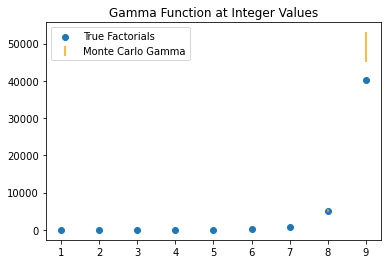

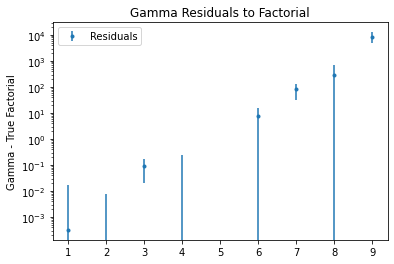

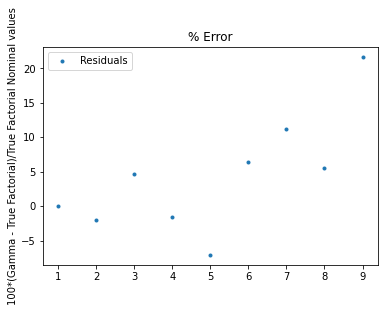

In [97]:
n=[1, 2, 3, 4, 5, 6, 7, 8, 9] #testing to see if it matches factorial
GammaNnominal=[]
GammaNerror=[]
NFactorial=[]
for i in range(len(n)): #just go over all the numbers and compute the factorial and the Gamma
    GammaNnominal.append(Gamma(n[i], 1000).n)
    GammaNerror.append(Gamma(n[i], 1000).s)
    NFactorial.append(scipy.special.factorial(n[i]-1))

plt.scatter(n, NFactorial, label='True Factorials')
plt.errorbar(n, GammaNnominal, yerr=GammaNerror, color='orange', linestyle='', label = 'Monte Carlo Gamma')
plt.title('Gamma Function at Integer Values')
plt.legend()
plt.show()

#let's also show residuals. The difference between this computation and the true factorial
plt.errorbar(n, np.array(GammaNnominal)-np.array(NFactorial), yerr=GammaNerror, label = 'Residuals', fmt='.')
plt.title('Gamma Residuals to Factorial')
plt.ylabel('Gamma - True Factorial')
plt.legend()
plt.yscale('log')
plt.show()

plt.errorbar(n, 100*(np.array(GammaNnominal)-np.array(NFactorial))/np.array(NFactorial), label = 'Residuals', fmt='.')
plt.title('% Error')
plt.ylabel('100*(Gamma - True Factorial)/True Factorial Nominal values')
plt.legend()
plt.show()
#looks not great lol but I think it's good. 6 seems weird but like big enough errorbars and it works

In [4]:
#part b.)
print('Gamma(5) with 100 itterations:', f'{Gamma(5, 100):.6f}')
print('Gamma(5) with 10000 itterations:', f'{Gamma(5, 10000):.6f}')
print('Gamma(5) with 1000000 itterations:', f'{Gamma(5, 1000000):.6f}')
print('Gamma(pi) with 100 itterations:', f'{Gamma(np.pi, 100):.6f}')
print('Gamma(pi) with 10000 itterations:', f'{Gamma(np.pi, 10000):.6f}')
print('Gamma(pi) with 1000000 itterations:', f'{Gamma(np.pi, 1000000):.6f}')

Gamma(5) with 100 itterations: 27.063218+/-4.113103
Gamma(5) with 10000 itterations: 23.957596+/-0.450639
Gamma(5) with 1000000 itterations: 24.099574+/-0.044399
Gamma(pi) with 100 itterations: 2.508941+/-0.273854
Gamma(pi) with 10000 itterations: 2.281176+/-0.029967
Gamma(pi) with 1000000 itterations: 2.289376+/-0.002947


In [125]:
#part c.)
#so gamma gets huuuuuuuge so let's try computing uhh the log of gamma(90)
#at which point if you wanted the real number you could just exponentiate

# def Gamma(z, N): #OK so Gamma is just defined as the integral so we plug that on in
#     Value = MCIntegral(lambda u: (1-u)**(z-1)/u**(z+1) * np.exp(-(1-u)/u), N, 0, 1) #This is u-subbed to have definite limits
#     Error = MCIntegralUncertainty(lambda u: (1-u)**(z-1)/u**(z+1) * np.exp(-(1-u)/u), N, 0, 1) #do the error
#     return(error.ufloat(Value, Error)) #the ufloat format doesn't end up geting used much

#So what we are going to do is take the log of (1-u)**(z-1)/u**(z+1) * np.exp(-(1-u)/u)
#This is nice and easy as it's going to be (z-1)*log(1-u) - (z+1)*log(u) -(1-u)/u
#The last term is just the exponent brought down, the other terms use log_e(a^b)=b*log_e(a)
#and some log rules so the / turns into a difference of logs. log(a/b)=log(a)-log(b)
#Now our math can work with smaller numbers just for a bit, we take the exponential of this basically right away

def logGamma(z, N):
    Value = MCIntegral(lambda u: np.exp(((z-1)*np.log(1-u) - (z+1)*np.log(u) - (1-u)/u)), N, 0, 1) #This is u-subbed to have definite limits
    Error = MCIntegralUncertainty(lambda u: np.exp(((z-1)*np.log(1-u) - (z+1)*np.log(u) - (1-u)/u)), N, 0, 1) #do the error
    return(error.ufloat(Value, Error)) #the ufloat format doesn't end up geting used much

print('logGamma(90) with 1000000 itterations:', logGamma(90, 1000000))

logGamma(90) with 1000000 itterations: (1.643+/-0.026)e+136


In [126]:
#let's see how it compares with the right result
scipy.special.factorial(89)
#yeah this is pretty spot on then

1.650795516090846e+136